1 - Preparação dos dados

In [3]:
import pandas as pd
import numpy as np

# Lista de colunas
col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "attack_type", "difficulty_level"
]

# Carregamento dos arquivos
train_df = pd.read_csv("/KDDTrain+.txt", header=None, names=col_names)
test_df  = pd.read_csv("/KDDTest+.txt",  header=None, names=col_names)

# Descartar coluna difficulty_level
train_df.drop(columns=["difficulty_level"], inplace=True)
test_df.drop(columns=["difficulty_level"],  inplace=True)

# Binarização do rótulo: normal → 0, qualquer ataque → 1
train_df["label"] = (train_df["attack_type"] != "normal").astype(int)
test_df["label"]  = (test_df["attack_type"]  != "normal").astype(int)

train_df.drop(columns=["attack_type"], inplace=True)
test_df.drop(columns=["attack_type"],  inplace=True)

# One-Hot Encoding dos atributos categóricos
cat_cols = ["protocol_type", "service", "flag"]

train_df = pd.get_dummies(train_df, columns=cat_cols)
test_df  = pd.get_dummies(test_df,  columns=cat_cols)

# Alinhar colunas: test pode ter categorias ausentes em relação ao treino
train_df, test_df = train_df.align(test_df, join="left", axis=1, fill_value=0)

# Separar features e rótulos
y_train = train_df["label"].values.astype(np.float32)
y_test  = test_df["label"].values.astype(np.float32)

X_train = train_df.drop(columns=["label"]).values.astype(np.float32)
X_test  = test_df.drop(columns=["label"]).values.astype(np.float32)

# Z-score usando APENAS estatísticas do treino
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)
std[std == 0] = 1  # evita divisão por zero

X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Features após one-hot: {X_train.shape[1]}")
print(f"Distribuição treino  — normal: {(y_train==0).sum()} | ataque: {(y_train==1).sum()}")
print(f"Distribuição teste   — normal: {(y_test==0).sum()}  | ataque: {(y_test==1).sum()}")

Treino: (125973, 122) | Teste: (22544, 122)
Features após one-hot: 122
Distribuição treino  — normal: 67343 | ataque: 58630
Distribuição teste   — normal: 9711  | ataque: 12833


2 - Implementação da MLP em PyTorch

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Reproducibilidade
torch.manual_seed(42)
np.random.seed(42)

# ── Conversão para tensores ──────────────────────────────────────────────────
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train).unsqueeze(1)   # (N, 1)
X_test_t  = torch.tensor(X_test)
y_test_t  = torch.tensor(y_test).unsqueeze(1)

# ── Divisão treino / validação (80/20, sem embaralhamento) ───────────────────
n_total = len(X_train_t)
n_val   = int(0.20 * n_total)
n_tr    = n_total - n_val

X_tr, X_val = X_train_t[:n_tr], X_train_t[n_tr:]
y_tr, y_val = y_train_t[:n_tr], y_train_t[n_tr:]

# ── DataLoaders ──────────────────────────────────────────────────────────────
BATCH_SIZE = 256

train_loader = DataLoader(TensorDataset(X_tr, y_tr),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val),
                          batch_size=BATCH_SIZE, shuffle=False)

# ── Definição da MLP ─────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            # Camada oculta 1
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Camada oculta 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Camada oculta 3
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            # Saída — SEM ativação (BCEWithLogitsLoss aplica sigmoid internamente)
            nn.Linear(32, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

# ── Instanciação ─────────────────────────────────────────────────────────────
INPUT_DIM = X_train.shape[1]
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model     = MLP(INPUT_DIM).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(model)
print(f"\nParâmetros treináveis: {sum(p.numel() for p in model.parameters()):,}")
print(f"Dispositivo: {device}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=122, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parâmetros treináveis: 26,561
Dispositivo: cpu


3 - Treinamento e Monitoramento

 Época |  Loss Treino |   Loss Val |     Status
--------------------------------------------------
     1 |      0.11243 |    0.02974 | ✔ melhor
     5 |      0.02442 |    0.01909 | ✔ melhor
    10 |      0.02034 |    0.01602 | ✔ melhor
    15 |      0.01720 |    0.01321 | ✔ melhor
    20 |      0.01624 |    0.01206 | 
    25 |      0.01548 |    0.01070 | 
    30 |      0.01479 |    0.01029 | 
    35 |      0.01383 |    0.01035 | 
    40 |      0.01361 |    0.00993 | 
    45 |      0.01317 |    0.00936 | ✔ melhor
    50 |      0.01337 |    0.00866 | ✔ melhor

Melhor val_loss: 0.00866


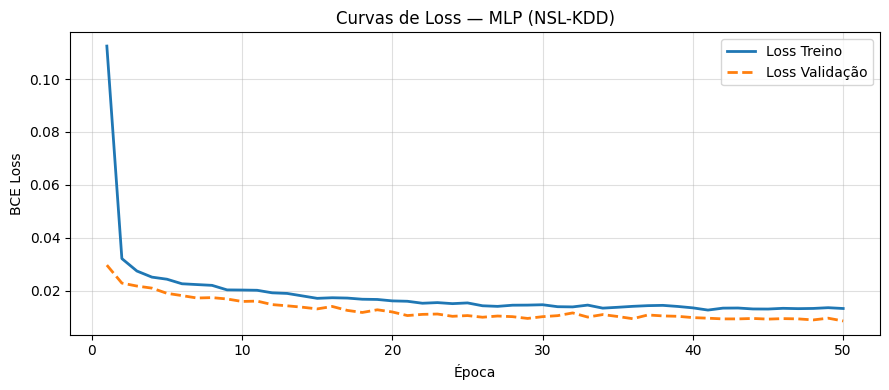

Figura salva em loss_curves.png


In [5]:
import matplotlib.pyplot as plt

EPOCHS        = 50
PATIENCE      = 8          # parada antecipada
best_val_loss = float("inf")
patience_cnt  = 0
best_state    = None

history = {"train_loss": [], "val_loss": []}

def epoch_loss(loader, train=False):
    """Calcula a loss média sobre um DataLoader."""
    model.train(train)
    total, n = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss   = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total += loss.item() * len(xb)
            n     += len(xb)
    return total / n

print(f"{'Época':>6} | {'Loss Treino':>12} | {'Loss Val':>10} | {'Status':>10}")
print("-" * 50)

for epoch in range(1, EPOCHS + 1):
    tr_loss  = epoch_loss(train_loader, train=True)
    val_loss = epoch_loss(val_loader,   train=False)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)

    # Parada antecipada
    status = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_cnt  = 0
        best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        status = "✔ melhor"
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"{epoch:>6} | {tr_loss:>12.5f} | {val_loss:>10.5f} | Parada antecipada")
            break

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6} | {tr_loss:>12.5f} | {val_loss:>10.5f} | {status}")

# Restaura os pesos do melhor checkpoint
model.load_state_dict(best_state)
print(f"\nMelhor val_loss: {best_val_loss:.5f}")

# ── Curvas de Loss ────────────────────────────────────────────────────────────
epochs_ran = len(history["train_loss"])

plt.figure(figsize=(9, 4))
plt.plot(range(1, epochs_ran + 1), history["train_loss"], label="Loss Treino",  linewidth=2)
plt.plot(range(1, epochs_ran + 1), history["val_loss"],   label="Loss Validação", linewidth=2, linestyle="--")
plt.xlabel("Época")
plt.ylabel("BCE Loss")
plt.title("Curvas de Loss — MLP (NSL-KDD)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150)
plt.show()
print("Figura salva em loss_curves.png")

4 - Avaliação do Conjunto de Teste

  Acurácia  : 0.7859  (78.59%)
  Precisão  : 0.9251
  Recall    : 0.6788
  F1-Score  : 0.7830

Matriz de Confusão:
              Pred Normal  Pred Ataque
Real Normal         9006         705
Real Ataque         4122        8711


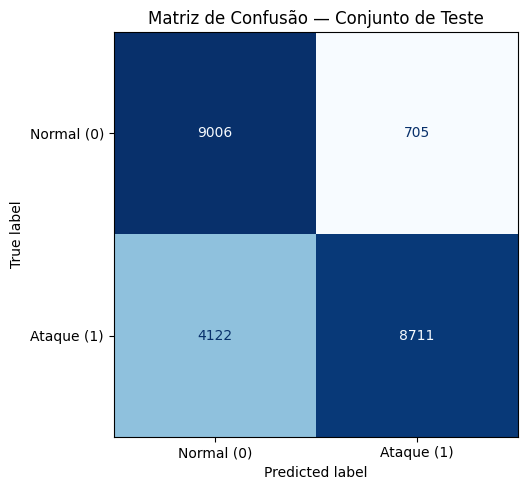

Figura salva em confusion_matrix.png


In [6]:
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score,
                             f1_score, ConfusionMatrixDisplay)

model.eval()
with torch.no_grad():
    logits_test = model(X_test_t.to(device)).cpu()
    probs_test  = torch.sigmoid(logits_test).numpy().flatten()

# Limiar de decisão = 0.5
THRESHOLD  = 0.5
y_pred     = (probs_test >= THRESHOLD).astype(int)
y_true     = y_test.astype(int)

# ── Métricas ──────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print("=" * 45)
print(f"  Acurácia  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precisão  : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 45)

# ── Matriz de Confusão ────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
print("\nMatriz de Confusão:")
print(f"              Pred Normal  Pred Ataque")
print(f"Real Normal   {cm[0,0]:>10}  {cm[0,1]:>10}")
print(f"Real Ataque   {cm[1,0]:>10}  {cm[1,1]:>10}")

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Normal (0)", "Ataque (1)"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de Confusão — Conjunto de Teste")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Figura salva em confusion_matrix.png")

5 - Análise do Limiar de Decisão

In [7]:
# ── Resposta impressa ──────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════════════╗
║          ANÁLISE DO LIMIAR DE DECISÃO EM IDS                           ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  Erro mais crítico: FALSO NEGATIVO                                       ║
║  → Um ataque classificado como normal NÃO é detectado.                   ║
║    Consequência: a rede permanece exposta, dados são comprometidos,      ║
║    podendo causar prejuízos financeiros e operacionais graves.           ║
║                                                                          ║
║  Falso positivo (conexão normal → ataque):                               ║
║    Gera alertas desnecessários e sobrecarrega a equipe de segurança,     ║
║    porém não representa risco direto à infraestrutura.                   ║
║                                                                          ║
║  Impacto no limiar:                                                      ║
║    Reduzir o limiar (ex.: 0.3 em vez de 0.5) aumenta o recall —         ║
║    detecta mais ataques — ao custo de mais falsos positivos.             ║
║    Em produção, limiares entre 0.2 e 0.4 são comuns em IDS,             ║
║    priorizando segurança sobre conveniência operacional.                 ║
╚══════════════════════════════════════════════════════════════════════════╝
""")

# ── Experimento com diferentes limiares ──────────────────────────────────────
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

print(f"{'Limiar':>8} | {'Acurácia':>9} | {'Precisão':>9} | {'Recall':>8} | {'F1':>8} | {'FN':>6} | {'FP':>6}")
print("-" * 72)

for thr in thresholds:
    yp = (probs_test >= thr).astype(int)
    cm_thr = confusion_matrix(y_true, yp)
    fn = cm_thr[1, 0]   # ataque previsto como normal
    fp = cm_thr[0, 1]   # normal previsto como ataque
    print(f"{thr:>8.1f} | "
          f"{accuracy_score(y_true, yp):>9.4f} | "
          f"{precision_score(y_true, yp, zero_division=0):>9.4f} | "
          f"{recall_score(y_true, yp):>8.4f} | "
          f"{f1_score(y_true, yp):>8.4f} | "
          f"{fn:>6} | {fp:>6}")


╔══════════════════════════════════════════════════════════════════════════╗
║          ANÁLISE DO LIMIAR DE DECISÃO EM IDS                           ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  Erro mais crítico: FALSO NEGATIVO                                       ║
║  → Um ataque classificado como normal NÃO é detectado.                   ║
║    Consequência: a rede permanece exposta, dados são comprometidos,      ║
║    podendo causar prejuízos financeiros e operacionais graves.           ║
║                                                                          ║
║  Falso positivo (conexão normal → ataque):                               ║
║    Gera alertas desnecessários e sobrecarrega a equipe de segurança,     ║
║    porém não representa risco direto à infraestrutura.                   ║
║                                                                          ║
